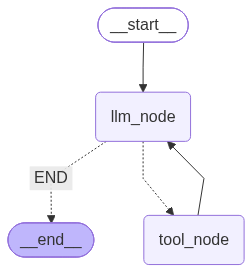

2026-09-04 15:28:59.937 | INFO     | __main__:wrap_tool_call:83 - 讲get_weather 的调用结果写入到缓存


LLM 返回: content='我来帮您查询北京的天气情况。' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 287, 'total_tokens': 339, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 256, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 256, 'prompt_cache_miss_tokens': 31}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': '2bf77959-d89e-467f-b78f-96446a5e2706', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--01a06b52-1e6d-7ab2-9f5e-80f58e0f89a8-0' tool_calls=[{'name': 'get_weather', 'args': {'city': '北京'}, 'id': 'call_00_oLx7PZbQHUnrBQZ47VgN2033', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 287, 'output_tokens': 52, 'total_tokens': 339, 'input_token_details': {'cache_read': 256}, 'output_token_details': {}}
是否有 tool_calls: Tru

KeyError: '__end__'

In [3]:
import json
import random
from langgraph.prebuilt import ToolNode, ToolRuntime
from langchain_core.messages import ToolMessage
from langgraph.graph import StateGraph, START, END, MessagesState, MessageGraph
from typing import TypedDict, Literal, Sequence, Annotated, Final, Tuple
from IPython.display import display
from langchain_deepseek import ChatDeepSeek
from dotenv import load_dotenv
from langchain.tools import tool
from loguru import logger
from langgraph.types import Send, Command, CachePolicy

from langchain.messages import HumanMessage, AIMessage, SystemMessage


load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    # temperature=0.7,
    extra_body={
        "thinking": {
            "type": "disabled",
        }
    }
)

@tool(parse_docstring=False)
def get_weather(city: str, runtime:ToolRuntime) -> Command:
    """
    查询指定城市的天气

    Args:
        city: 城市名称
    """
    rand_int=random.randint(1,10)
    if rand_int <5:
        logger.info("网络波动，请重试")
        raise ConnectionError("网络错误")
    return f"城市 {city} 的天气是晴朗***********"

tools = [get_weather]
model_with_tool = model.bind_tools(tools=tools)


def llm_node(state:MessagesState)->MessageGraph:
    messages = state["messages"]
    res = model_with_tool.invoke(messages)


    # 调试输出
    print(f"LLM 返回: {res}")
    print(f"是否有 tool_calls: {hasattr(res, 'tool_calls')}")
    print(f"tool_calls 内容: {res.tool_calls if hasattr(res, 'tool_calls') else 'None'}")
    return {
        "messages": [res]
    }

def router(state:MessagesState)-> Literal["tool_node", END]:
    # last_msg = state["messages"][-1]
    # 检查是否有 tool_calls 属性
    # if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
    if state["messages"][-1].tool_calls:
        return "tool_node"
    return END

global_cache = dict()
def wrap_tool_call(request, execute):
    tool_name = request.tool_call["name"]
    tool_args = json.dumps(request.tool_call["args"])
    tool_call_id = request.runtime.tool_call_id
    cache_key = (tool_name, tool_args)
    cache = global_cache.get(cache_key)
    if cache:
        logger.info("{} 调用缓存命中。".format(tool_name))
        tool_msg = ToolMessage(
            tool_call_id=tool_call_id,
            content=cache,
        )
    else:
        tool_msg = execute(request)
        logger.info("讲{} 的调用结果写入到缓存".format(tool_name))
        global_cache[cache_key] = tool_msg.content
    return tool_msg


builder = StateGraph(state_schema=MessagesState)
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", ToolNode(tools=tools, wrap_tool_call=wrap_tool_call))
builder.add_edge(START, "llm_node")
builder.add_conditional_edges("llm_node", router, path_map={"tool_node":"tool_node","END": END})
builder.add_edge("tool_node", "llm_node")

graph = builder.compile()
display(graph)
res = graph.invoke({"messages": [HumanMessage(content="北京天气怎么样？")]})
for msg in res["messages"]:
    msg.pretty_print()





In [5]:
res = graph.invoke({"messages": [HumanMessage(content="北京天气怎么样？")]})
for msg in res["messages"]:
    msg.pretty_print()

2026-09-04 15:30:03.266 | INFO     | __main__:wrap_tool_call:76 - get_weather 调用缓存命中。


LLM 返回: content='我来帮您查询北京的天气情况。' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 287, 'total_tokens': 338, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 256, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 256, 'prompt_cache_miss_tokens': 31}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': 'c5692c0c-5dc9-473c-94ca-ce91f1998191', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--01a06b53-1408-7131-82c3-f63bb855e86d-0' tool_calls=[{'name': 'get_weather', 'args': {'city': '北京'}, 'id': 'call_00_79uOkMzXhZauBqJ5bNBR7415', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 287, 'output_tokens': 51, 'total_tokens': 338, 'input_token_details': {'cache_read': 256}, 'output_token_details': {}}
是否有 tool_calls: Tru

KeyError: '__end__'